In [2]:
# -----------------------------
# 0) Imports + Settings
# -----------------------------
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

pd.set_option("display.max_columns", 200)
np.random.seed(42)


In [1]:
# -----------------------------
# 1) Load Data
# -----------------------------
# Update this path to your CSV
DATA_PATH = "../../data/processed/NOAA/NOAA_Global_Bleaching_Cleaned.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df


NameError: name 'pd' is not defined

In [8]:
# -----------------------------
# 2) Basic cleaning
# -----------------------------
# Strip whitespace from column names
df.columns = [c.strip() for c in df.columns]

# Parse Date if present
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Quick glance at missingness
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)


Unnamed: 0                          0.0
Latitude_Degrees                    0.0
SSTA_FrequencyMean                  0.0
SSTA_DHW                            0.0
SSTA_DHW_Standard_Deviation         0.0
SSTA_DHWMax                         0.0
SSTA_DHWMean                        0.0
TSA                                 0.0
TSA_Standard_Deviation              0.0
TSA_Minimum                         0.0
TSA_Maximum                         0.0
TSA_Mean                            0.0
TSA_Frequency                       0.0
TSA_Frequency_Standard_Deviation    0.0
TSA_FrequencyMax                    0.0
TSA_FrequencyMean                   0.0
TSA_DHW                             0.0
TSA_DHW_Standard_Deviation          0.0
TSA_DHWMax                          0.0
TSA_DHWMean                         0.0
dtype: float64

In [9]:
# -----------------------------
# 3) Define Targets + Features
# -----------------------------
# Primary regression target
TARGET_REG = "Percent_Bleaching"

# Optional classification target
TARGET_CLS = "Bleaching_Level"

# Columns you typically should NOT use as predictors (free-text + comments)
drop_text = [c for c in df.columns if "Comments" in c] + ["Site_Comments", "Sample_Comments", "Bleaching_Comments"]
drop_text = [c for c in drop_text if c in df.columns]

# You may or may not want to drop Date (keep it if you do time-based analyses)
# For baseline modeling, we’ll turn Date into year/month features (optional).
use_date_features = "Date" in df.columns

# Keep a copy
data = df.copy()

# Ensure target is numeric so it remains in corr
if "Percent Bleaching" in data.columns and "Percent_Bleaching" not in data.columns:
    data = data.rename(columns={"Percent Bleaching": "Percent_Bleaching"})
if "Percent_Bleaching" in data.columns:
    data["Percent_Bleaching"] = pd.to_numeric(data["Percent_Bleaching"], errors="coerce")

# Create simple date features (optional)
if use_date_features:
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month

# Candidate predictors (exclude targets and text)
exclude = set([TARGET_REG, TARGET_CLS, "Date"]) | set(drop_text)
feature_cols = [c for c in data.columns if c not in exclude]

# If you want to remove raw lat/long from non-spatial models, uncomment:
# Normalize mixed-type feature columns to avoid OneHotEncoder errors
for c in feature_cols:
    if data[c].dtype == "object":
        as_num = pd.to_numeric(data[c], errors="coerce")
        if as_num.notna().mean() >= 0.9:
            data[c] = as_num
        else:
            data[c] = data[c].astype("string")

# feature_cols = [c for c in feature_cols if c not in ["Latitude_Degrees", "Longitude_Degrees"]]

print("Num features:", len(feature_cols))
feature_cols[:20]


Num features: 44


['Unnamed: 0',
 'Latitude_Degrees',
 'Longitude_Degrees',
 'Ocean_Name',
 'Distance_to_Shore',
 'Exposure',
 'Turbidity',
 'Cyclone_Frequency',
 'Depth_m',
 'Percent_Cover',
 'ClimSST',
 'Temperature_Kelvin',
 'Temperature_Mean',
 'Temperature_Minimum',
 'Temperature_Maximum',
 'Temperature_Kelvin_Standard_Deviation',
 'SSTA',
 'SSTA_Standard_Deviation',
 'SSTA_Mean',
 'SSTA_Minimum']

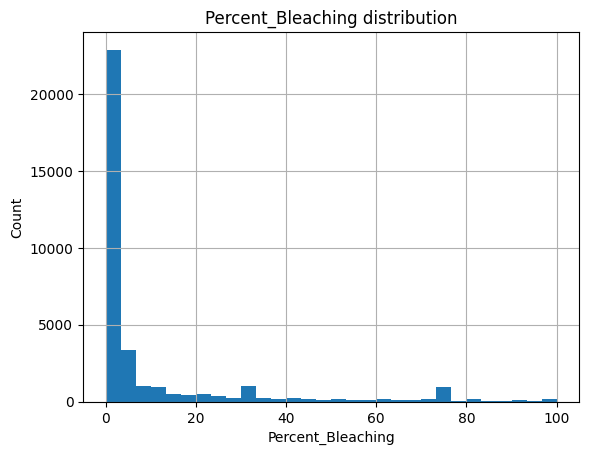

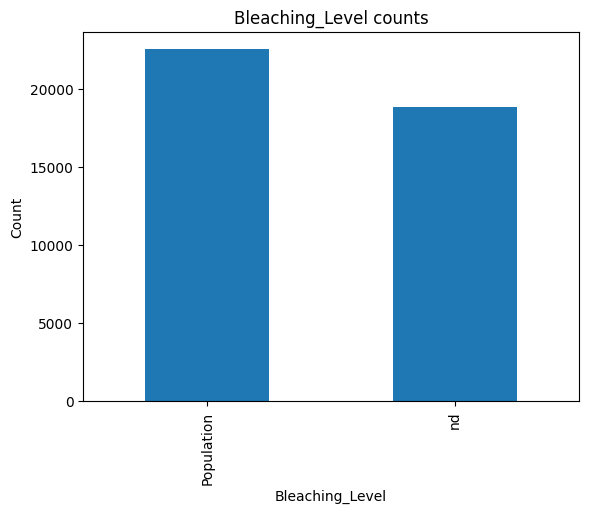

In [10]:
# -----------------------------
# 4) Quick EDA
# -----------------------------
# Distribution of Percent_Bleaching
if TARGET_REG in data.columns:
    plt.figure()
    data[TARGET_REG].dropna().hist(bins=30)
    plt.title("Percent_Bleaching distribution")
    plt.xlabel("Percent_Bleaching")
    plt.ylabel("Count")
    plt.show()

# If Bleaching_Level exists, show counts
if TARGET_CLS in data.columns:
    plt.figure()
    data[TARGET_CLS].astype("category").value_counts(dropna=False).plot(kind="bar")
    plt.title("Bleaching_Level counts")
    plt.xlabel("Bleaching_Level")
    plt.ylabel("Count")
    plt.show()


In [12]:
# -----------------------------
# 5) Correlation (numeric only) — helps detect redundancy
# -----------------------------
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(data[c])]
corr = data[numeric_cols + ([TARGET_REG] if TARGET_REG in data.columns else [])].corr(numeric_only=True)

# Show top correlations with target
if TARGET_REG in data.columns and TARGET_REG in corr.columns:
    target_corr = corr[TARGET_REG].drop(TARGET_REG).sort_values(key=lambda s: s.abs(), ascending=False)
    target_corr.head(15)
else:
    print("Target not found for correlation analysis.")

target_corr


SSTA_DHW                                 0.272392
TSA_DHW                                  0.272091
Year                                    -0.214274
SSTA_Frequency                           0.188832
Depth_m                                  0.165545
TSA_Frequency                            0.162356
Longitude_Degrees                       -0.144262
TSA                                      0.142379
SSTA_Standard_Deviation                  0.137434
SSTA                                     0.119348
Temperature_Kelvin                       0.107627
TSA_Frequency_Standard_Deviation        -0.101926
SSTA_Frequency_Standard_Deviation       -0.092733
TSA_FrequencyMax                        -0.085899
SSTA_FrequencyMax                       -0.078374
TSA_Mean                                -0.072845
SSTA_FrequencyMean                      -0.072664
Temperature_Mean                        -0.064810
SSTA_DHWMax                             -0.051755
Latitude_Degrees                         0.051453


In [13]:
# -----------------------------
# 6) Train/Test Split (Regression)
# -----------------------------
# Keep only rows with target for regression
reg_df = data.dropna(subset=[TARGET_REG]).copy()

X = reg_df[feature_cols]
y = reg_df[TARGET_REG]

# Identify categorical vs numeric predictors
cat_cols = [c for c in feature_cols if (not pd.api.types.is_numeric_dtype(reg_df[c]))]
num_cols = [c for c in feature_cols if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

len(X_train), len(X_test)

(27612, 6903)

In [14]:
# -----------------------------
# 7) Preprocessing Pipeline
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

preprocess


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [15]:
# Normalize mixed-type feature columns
for c in feature_cols:
    if data[c].dtype == "object":
        as_num = pd.to_numeric(data[c], errors="coerce")
        if as_num.notna().mean() >= 0.9:
            data[c] = as_num
        else:
            data[c] = data[c].astype("string")

In [11]:
# -----------------------------
# 8) Baseline Regression Models
# -----------------------------
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    )
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, pred)

    results.append((name, mae, rmse, r2))

res_df = pd.DataFrame(results, columns=["model", "MAE", "RMSE", "R2"]).sort_values("RMSE")
res_df


,model,MAE,RMSE,R2
2,RandomForestRegressor,2.365205,6.930135,0.881627
0,LinearRegression,9.720017,15.714454,0.391351
1,Ridge,9.763981,15.728750,0.390243


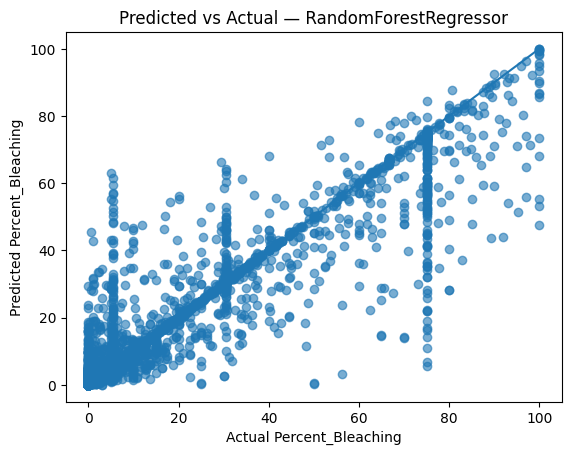

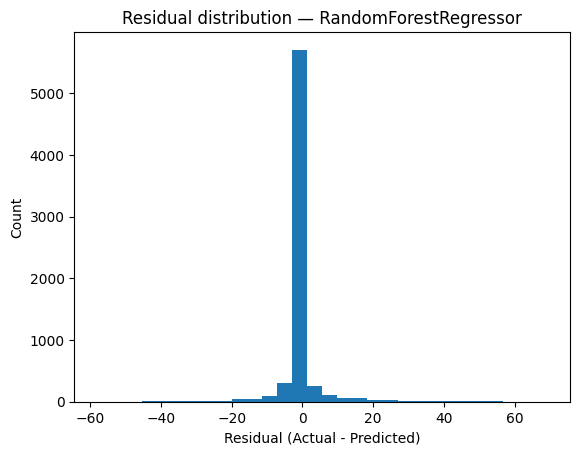

In [12]:
# -----------------------------
# 9) Plot Predictions vs Actual (best model)
# -----------------------------
best_name = res_df.iloc[0]["model"]
best_model = models[best_name]

best_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", best_model)])
best_pipe.fit(X_train, y_train)
pred = best_pipe.predict(X_test)

plt.figure()
plt.scatter(y_test, pred, alpha=0.6)
plt.title(f"Predicted vs Actual — {best_name}")
plt.xlabel("Actual Percent_Bleaching")
plt.ylabel("Predicted Percent_Bleaching")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

# Residuals
residuals = y_test - pred
plt.figure()
plt.hist(residuals, bins=30)
plt.title(f"Residual distribution — {best_name}")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.show()


In [13]:
# -----------------------------
# 10) Feature Importance (Random Forest only)
# -----------------------------
# Only works if best model is the RandomForestRegressor
if best_name == "RandomForestRegressor":
    # Fit to all data for more stable importances
    best_pipe.fit(X, y)

    # Get feature names out of preprocess
    ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = list(ohe.get_feature_names_out(cat_cols)) if len(cat_cols) else []
    feature_names = num_cols + cat_feature_names

    importances = best_pipe.named_steps["model"].feature_importances_
    imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    imp.head(20)
else:
    print("Feature importances shown only when RandomForestRegressor is selected as best model.")


KeyboardInterrupt: 

Best breakpoint for SSTA_DHW: 8.010 (lower SSE=12772823.29)


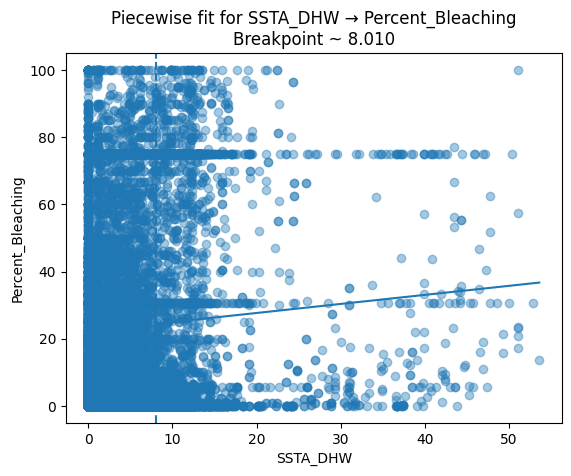

In [14]:
# -----------------------------
# 11) DHW Threshold / “Tipping Point” (Piecewise Linear Search)
# -----------------------------
# This finds the best breakpoint for a chosen stress metric vs Percent_Bleaching.
# Works best with SSTA_DHW (or TSA_DHW) and enough samples.

candidate_x = None
for col in ["SSTA_DHW", "TSA_DHW", "SSTA", "TSA"]:
    if col in reg_df.columns and pd.api.types.is_numeric_dtype(reg_df[col]):
        candidate_x = col
        break

if candidate_x is None:
    print("No DHW/anomaly column found for threshold analysis.")
else:
    tmp = reg_df[[candidate_x, TARGET_REG]].dropna().copy()
    tmp = tmp.sort_values(candidate_x)
    x = tmp[candidate_x].values
    y2 = tmp[TARGET_REG].values

    # Breakpoints to try (avoid extremes)
    qs = np.linspace(0.1, 0.9, 41)
    breakpoints = np.quantile(x, qs)

    def fit_piecewise(bp):
        left = x <= bp
        right = x > bp
        # y = a + b*x on left, and c + d*x on right
        # Fit separate least squares
        if left.sum() < 20 or right.sum() < 20:
            return np.inf, None

        Xl = np.c_[np.ones(left.sum()), x[left]]
        Xr = np.c_[np.ones(right.sum()), x[right]]

        bl = np.linalg.lstsq(Xl, y2[left], rcond=None)[0]
        br = np.linalg.lstsq(Xr, y2[right], rcond=None)[0]

        pred_left = Xl @ bl
        pred_right = Xr @ br
        sse = ((y2[left] - pred_left) ** 2).sum() + ((y2[right] - pred_right) ** 2).sum()
        return sse, (bl, br)

    best_sse = np.inf
    best_bp = None
    best_params = None

    for bp in breakpoints:
        sse, params = fit_piecewise(bp)
        if sse < best_sse:
            best_sse, best_bp, best_params = sse, bp, params

    print(f"Best breakpoint for {candidate_x}: {best_bp:.3f} (lower SSE={best_sse:.2f})")

    bl, br = best_params
    # Plot
    plt.figure()
    plt.scatter(x, y2, alpha=0.4)
    plt.title(f"Piecewise fit for {candidate_x} → Percent_Bleaching\nBreakpoint ~ {best_bp:.3f}")
    plt.xlabel(candidate_x)
    plt.ylabel("Percent_Bleaching")

    # Lines
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = np.where(
        x_line <= best_bp,
        bl[0] + bl[1] * x_line,
        br[0] + br[1] * x_line
    )
    plt.plot(x_line, y_line)
    plt.axvline(best_bp, linestyle="--")
    plt.show()


/Users/coreylu/Documents/CAAAral_Reefs/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



LogisticRegression
              precision    recall  f1-score   support

  Population       0.92      0.97      0.95      4507
          nd       0.97      0.90      0.93      3766

    accuracy                           0.94      8273
   macro avg       0.94      0.94      0.94      8273
weighted avg       0.94      0.94      0.94      8273



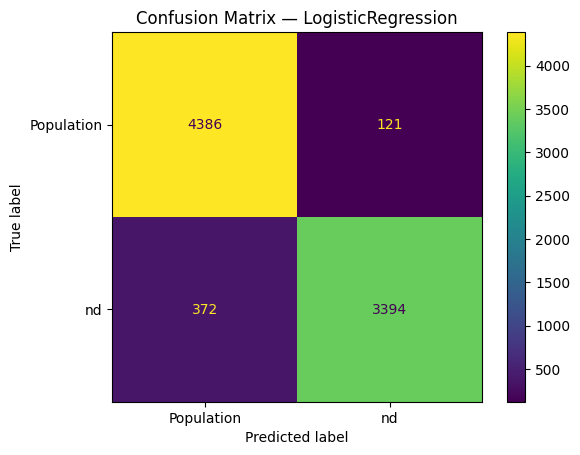


RandomForestClassifier
              precision    recall  f1-score   support

  Population       0.98      1.00      0.99      4507
          nd       1.00      0.97      0.99      3766

    accuracy                           0.99      8273
   macro avg       0.99      0.99      0.99      8273
weighted avg       0.99      0.99      0.99      8273



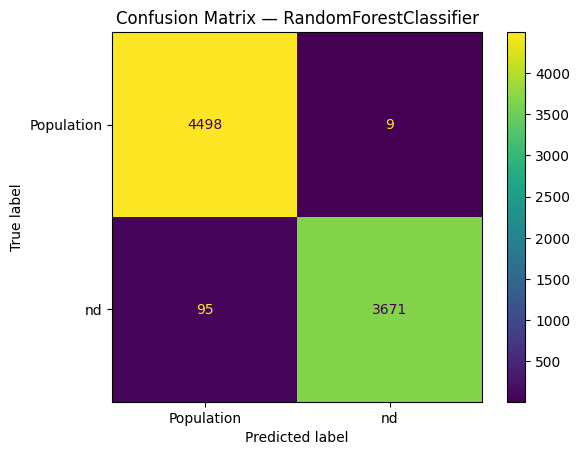

In [15]:
# -----------------------------
# 12) OPTIONAL: Classification Model (Bleaching_Level)
# -----------------------------
if TARGET_CLS not in data.columns:
    print("Bleaching_Level column not found.")
else:
    cls_df = data.dropna(subset=[TARGET_CLS]).copy()

    Xc = cls_df[feature_cols]
    yc = cls_df[TARGET_CLS].astype(str)

    cat_cols_c = [c for c in feature_cols if (not pd.api.types.is_numeric_dtype(cls_df[c]))]
    num_cols_c = [c for c in feature_cols if c not in cat_cols_c]

    Xc_train, Xc_test, yc_train, yc_test = train_test_split(
        Xc, yc, test_size=0.2, random_state=42, stratify=yc
    )

    preprocess_c = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                              ("scaler", StandardScaler())]), num_cols_c),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                              ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_c),
        ]
    )

    clf_models = {
        "LogisticRegression": LogisticRegression(max_iter=500, n_jobs=-1),
        "RandomForestClassifier": RandomForestClassifier(
            n_estimators=500, random_state=42, n_jobs=-1, min_samples_leaf=2
        )
    }

    for name, clf in clf_models.items():
        pipe_c = Pipeline([("preprocess", preprocess_c), ("model", clf)])
        pipe_c.fit(Xc_train, yc_train)
        pred_c = pipe_c.predict(Xc_test)

        print("\n", "="*60)
        print(name)
        print(classification_report(yc_test, pred_c))

        cm = confusion_matrix(yc_test, pred_c, labels=sorted(yc.unique()))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(yc.unique()))
        disp.plot(values_format="d")
        plt.title(f"Confusion Matrix — {name}")
        plt.show()


In [4]:
df["Bleaching_Level"].unique()

array(['nd', 'Population'], dtype=object)